In [ ]:
!pip install prophet

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from prophet import Prophet

In [ ]:
df = pd.read_csv("master_influenza_dataset.csv")

# Clean column names
df.columns = df.columns.str.strip()

# Convert Date
df['Date'] = pd.to_datetime(df['Date'])

df.head()

,Year,Week,ILI_Total,Total_Patients,Weighted_ILI,Region,Season,Date,Population_2024,ILI_per_100k
0,2019,40,5637,333469,1.67601,Region 4,2019_20,2019-09-30,70994814.0,7.940017
1,2019,41,5349,317260,1.63170,Region 4,2019_20,2019-10-07,70994814.0,7.534353
2,2019,42,5711,311644,1.81532,Region 4,2019_20,2019-10-14,70994814.0,8.044250
3,2019,43,6683,322052,1.96609,Region 4,2019_20,2019-10-21,70994814.0,9.413364
4,2019,44,7119,318970,2.29988,Region 4,2019_20,2019-10-28,70994814.0,10.027493


In [ ]:
region = 'Region 4'

data = df[df['Region'] == region].copy()
data = data.sort_values('Date')

In [ ]:
prophet_df = data[['Date', 'Weighted_ILI']].copy()

prophet_df.rename(columns={
    'Date': 'ds',
    'Weighted_ILI': 'y'
}, inplace=True)

# Handle missing values
prophet_df['y'] = prophet_df['y'].fillna(method='ffill')

prophet_df.head()

/tmp/ipykernel_15712/3284426332.py:9: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  prophet_df['y'] = prophet_df['y'].fillna(method='ffill')


,ds,y
0,2019-09-30,1.67601
1,2019-10-07,1.63170
2,2019-10-14,1.81532
3,2019-10-21,1.96609
4,2019-10-28,2.29988


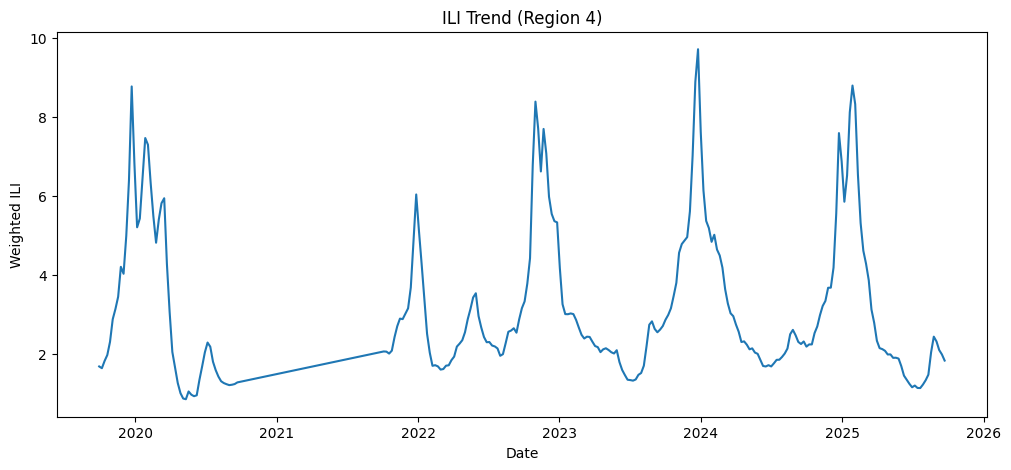

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(prophet_df['ds'], prophet_df['y'])
plt.title(f"ILI Trend ({region})")
plt.xlabel("Date")
plt.ylabel("Weighted ILI")
plt.show()

In [ ]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.8   # ✅ flexibility
)

# Add custom yearly seasonality (optional but powerful)
model.add_seasonality(
    name='yearly_custom',
    period=365,
    fourier_order=15
)

In [ ]:
model.fit(prophet_df)

In [ ]:
future = model.make_future_dataframe(periods=20, freq='W')
future.tail()

,ds
275,2026-01-11
276,2026-01-18
277,2026-01-25
278,2026-02-01
279,2026-02-08


In [ ]:
forecast = model.predict(future)

forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head()

,ds,yhat,yhat_lower,yhat_upper
0,2019-09-30,0.918487,-0.058602,1.868696
1,2019-10-07,1.797439,0.805541,2.665885
2,2019-10-14,2.023714,0.995348,3.032799
3,2019-10-21,2.304924,1.331669,3.257235
4,2019-10-28,2.979762,2.058626,3.956801


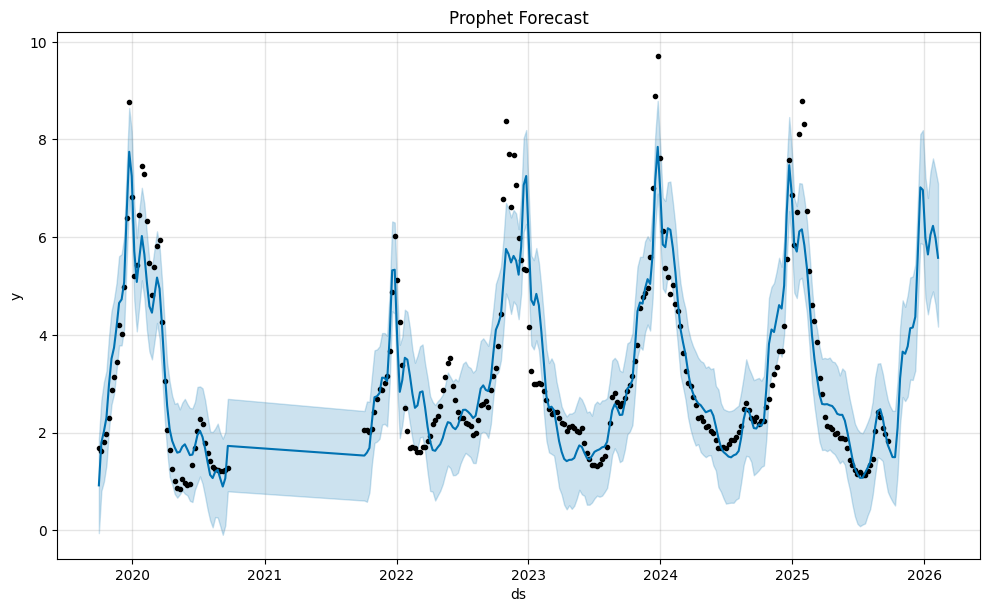

In [ ]:
fig1 = model.plot(forecast)
plt.title("Prophet Forecast")
plt.show()

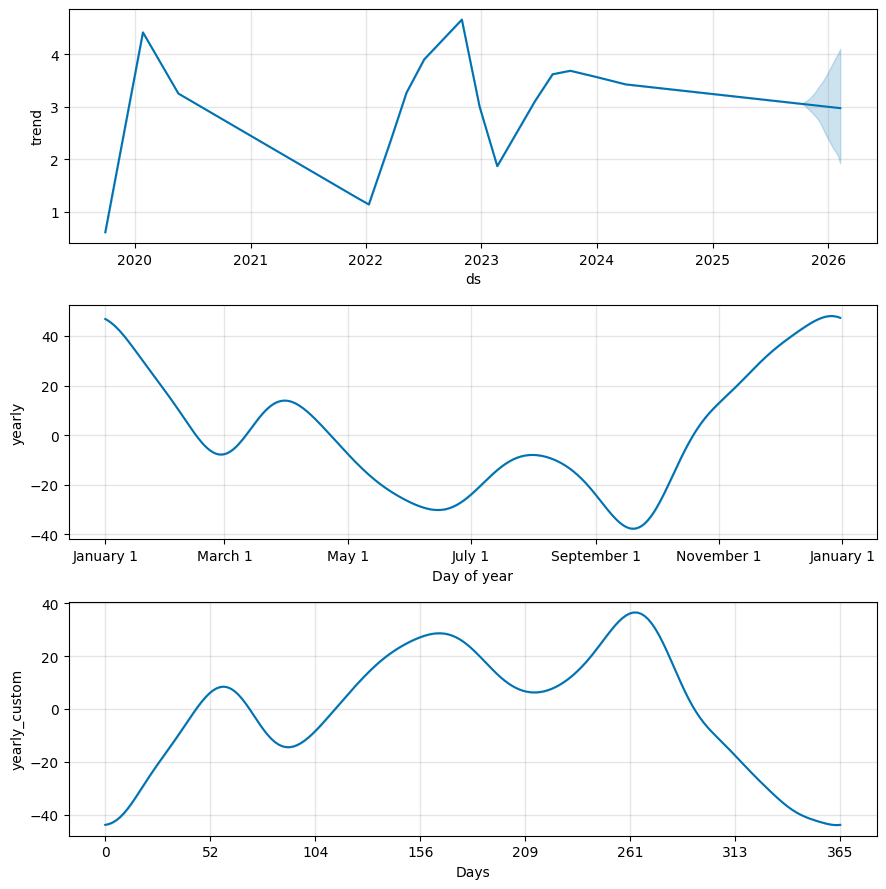

In [ ]:
fig2 = model.plot_components(forecast)
plt.show()

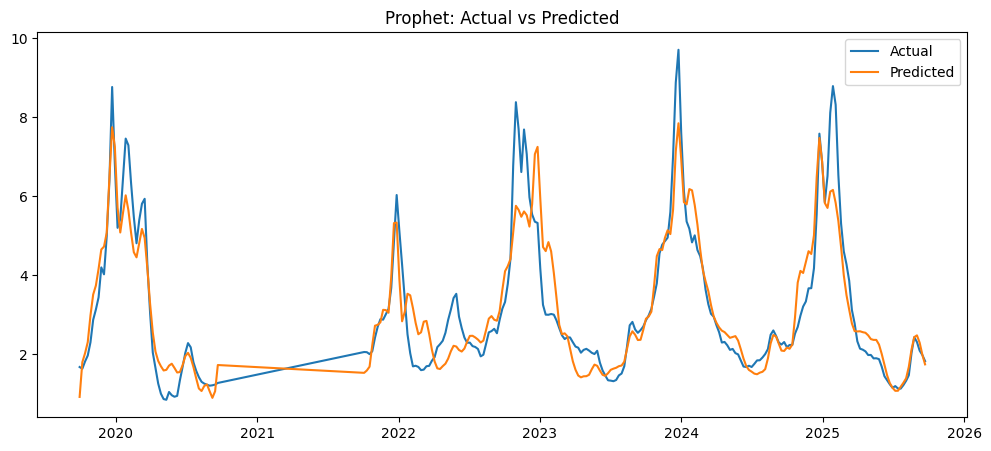

In [ ]:
# Merge actual and forecast
merged = prophet_df.merge(
    forecast[['ds', 'yhat']],
    on='ds',
    how='left'
)

plt.figure(figsize=(12,5))
plt.plot(merged['ds'], merged['y'], label='Actual')
plt.plot(merged['ds'], merged['yhat'], label='Predicted')

plt.legend()
plt.title("Prophet: Actual vs Predicted")
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error

# Drop NaNs
eval_df = merged.dropna()

rmse = np.sqrt(mean_squared_error(eval_df['y'], eval_df['yhat']))

print("RMSE:", rmse)

RMSE: 0.7380307949412637
